
# Data Mining Assignment 3 – Clustering and Anomaly Detection
## Task 1: Data Exploration & Preprocessing

---
### 0. Imports and configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os 
import json
import re
import scipy.sparse
import pickle

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer

# paths creation need to adapt with yours
path = r'C:\Users\ephts\OneDrive\Documents\Master UA\Data mining\A3' 

data_path = os.path.join(path, 'datas')
preprocessed = os.path.join(path, 'preprocessed')
figures = os.path.join(path, 'fig')

ARTICLE_PATH = os.path.join(data_path,'articles.csv')

print('Imported and paths created')


Imported and paths created


---
### 1. Loading table

In [2]:
article = pd.read_csv(ARTICLE_PATH) 
print('-----ARTICLE-----')
print(f'Shapes : {article.shape}')
print("Columns:", article.columns.tolist())
print(article.head())

TEXT_COL = "text"   
ID = "doc_id"       

-----ARTICLE-----
Shapes : (2164, 2)
Columns: ['doc_id', 'text']
      doc_id                                               text
0  DOC_00001  When I first saw this, I thought for a second ...
1  DOC_00002  The difficulties of a high Isp OTV include: Lo...
2  DOC_00003  Forwarded from Neal Ausman, Galileo Mission Di...
3  DOC_00004  Sjogren's syndrome has been known to induce dr...
4  DOC_00005  Yes, I want to concentrate on other developmen...


## 2. First explorations

In [4]:

# basic null check
print("\nMissing values:")
print(article.isnull().sum())

# keep only rows where text exists
article = article.dropna(subset=[TEXT_COL]).copy()

# text length statistics
article["char_length"] = article[TEXT_COL].astype(str).apply(len)
article["word_count"] = article[TEXT_COL].astype(str).apply(lambda x: len(x.split()))

print("\nWord count statistics:")
print(article["word_count"].describe())

print("\nText length statistics:")
print(article['char_length'].describe())


Missing values:
doc_id         0
text           0
char_length    0
word_count     0
dtype: int64

Word count statistics:
count    2164.000000
mean      151.219039
std       228.399709
min        25.000000
25%        59.000000
50%        95.000000
75%       165.000000
max      6863.000000
Name: word_count, dtype: float64

Text length statistics:
count     2164.000000
mean       886.481978
std       1153.780295
min        201.000000
25%        346.000000
50%        546.000000
75%        968.000000
max      24514.000000
Name: char_length, dtype: float64


---
### 3. Visualization

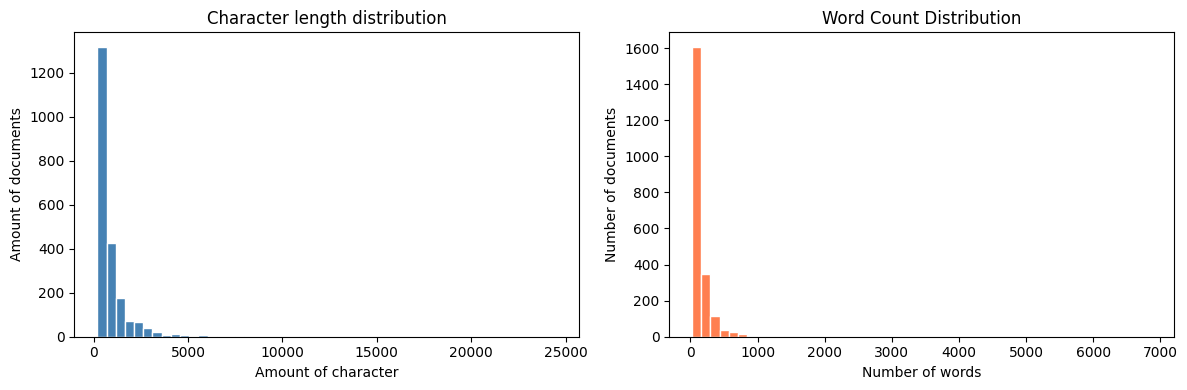

              count  percentage  cumulative_percentage
word_count                                            
(0, 50]         357   16.497227              16.497227
(50, 100]       784   36.229205              52.726433
(100, 200]      609   28.142329              80.868762
(200, 500]      332   15.341959              96.210721
(500, 1000]      64    2.957486              99.168207
(1000, 2000]     15    0.693161              99.861368
(2000, 6863]      3    0.138632             100.000000
Figure saved


In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Character length distribution
ax1.hist(article['char_length'], bins=50, color='steelblue', edgecolor='white')
ax1.set_title('Character length distribution')
ax1.set_xlabel('Amount of character')
ax1.set_ylabel('Amount of documents')

# Word count distribution
ax2.hist(article['word_count'], bins=50, color='coral', edgecolor='white')
ax2.set_title('Word Count Distribution')
ax2.set_xlabel('Number of words')
ax2.set_ylabel('Number of documents')

plt.tight_layout()
plt.savefig(os.path.join(figures, 'text_length_distribution.png'), dpi=150)
plt.show()

max_word = article["word_count"].max()
bins = [0, 50, 100, 200, 500, 1000, 2000, max_word]
counts = pd.cut(article["word_count"], bins=bins).value_counts().sort_index()
percentages = (counts / len(article)) * 100

stats_df = pd.DataFrame({
    "count": counts,
    "percentage": percentages
})
stats_df["cumulative_percentage"] = stats_df["percentage"].cumsum()

print(stats_df)

print("Figure saved")

---
### 4. Possible anomalies


In [6]:
# Only 18 articles out of 2164 have more than 2000 words.
# These are potential anomaly candidates based on length only.
# This is not a final decision and will be revisited in Task 3.

top_outliers = article.sort_values("word_count", ascending=False).head(3)

outliers_info = top_outliers[["doc_id", "word_count"]].to_dict(orient="records")

json_path = os.path.join(preprocessed, "length_outliers.json")

with open(json_path, "w") as f:
    json.dump(outliers_info, f, indent=4)

print("Outliers saved to:", json_path)

Outliers saved to: C:\Users\ephts\OneDrive\Documents\Master UA\Data mining\A3\preprocessed\length_outliers.json


---
### 5. Cleaning articles

In [7]:
def clean_text(text):
    text = text.lower()                          # lowercase
    text = re.sub(r'\S+@\S+', '', text)         # remove emails
    text = re.sub(r'http\S+|www\S+', '', text)  # remove URLs
    text = re.sub(r'[^a-z\s]', ' ', text)       # remove punctuation 
    text = re.sub(r'\s+', ' ', text).strip()    # remove extra spaces
    return text

article['text_clean'] = article[TEXT_COL].apply(clean_text)

print("=== BEFORE ===")
print(article[TEXT_COL].iloc[0][:300])
print("\n=== AFTER ===")
print(article['text_clean'].iloc[0][:300])

=== BEFORE ===
When I first saw this, I thought for a second that it was a headline from The Star about the pliers found in the SRB recently. Y'know, sometimes they have wire-cutters built in :-) -Tommy Mac ------------------------------------------------------------------------- Tom McWilliams 517-355-2178 wk \\ 

=== AFTER ===
when i first saw this i thought for a second that it was a headline from the star about the pliers found in the srb recently y know sometimes they have wire cutters built in tommy mac tom mcwilliams wk as the radius of vision increases hm the circumference of mystery grows


In [8]:
stopwords = set(ENGLISH_STOP_WORDS)
print(f"Total stopwords: {len(stopwords)}")

Total stopwords: 318


---
### 6. TF-IDF

In [9]:
vectorizer = TfidfVectorizer(
    stop_words=list(stopwords),   # remove stopwords
    max_features=5000,            # keep only top 5000 words
    min_df=5,                     # word must appear in at least 5 documents
    max_df=0.80,                  # word must not appear in more than 80% of documents
    ngram_range=(1, 2),           # unigrams AND bigrams ("space shuttle", "ice hockey")
    sublinear_tf=True,            # apply log(1+tf) to reduce impact of very frequent words
)

article["processed_text_v1"] = article["text_clean"]
X = vectorizer.fit_transform(article["processed_text_v1"])

print(f"Matrix shape: {X.shape}")


Matrix shape: (2164, 5000)


---
### 7. Explore the TDF-IDF matrix

In [10]:
feature_names = vectorizer.get_feature_names_out()
tfidf_sum = np.asarray(X.sum(axis=0)).flatten()
top_idx = tfidf_sum.argsort()[-200:][::-1]

print("Top 200 terms by global TF-IDF weight:")
for i in top_idx:
    print(f"  {feature_names[i]:<25} {tfidf_sum[i]:.2f}")

Top 200 terms by global TF-IDF weight:
  like                      42.18
  don                       38.31
  just                      37.69
  know                      37.20
  think                     34.06
  good                      30.62
  time                      29.99
  does                      28.37
  car                       27.42
  people                    26.59
  new                       25.20
  thanks                    25.03
  use                       23.86
  space                     23.35
  way                       22.67
  ve                        22.47
  need                      20.98
  year                      20.80
  make                      20.59
  game                      20.47
  did                       19.99
  right                     19.91
  really                    19.67
  years                     19.54
  want                      19.25
  got                       19.10
  problem                   19.01
  help                      18.99
  team   

---
### 8. Addition of stopwords

In [11]:
# in the above list we observe that conversational are still present and dont bring value
extra_stopwords = {
    'like', 'just', 'know', 'think', 'really',
    'hi', 'yes', 'maybe', 'probably', 'actually',
    've', 'll', 'don', 'didn', 'doesn', 'isn',
    'going', 'got', 'let', 'say', 'said',
    'look', 'come', 'seen', 'trying','i','a'
}

all_stopwords = list(stopwords | extra_stopwords)
print(f"Total stopwords: {len(all_stopwords)}")

Total stopwords: 343


---
### 8. Redo TF-IDF

In [12]:
# we redo tf-idf with the updated stopwords

vectorizer_final = TfidfVectorizer(
    stop_words=all_stopwords,
    max_features=5000,
    min_df=5,
    max_df=0.80,
    ngram_range=(1, 2),
    sublinear_tf=True,
)

article["processed_text"] = article["text_clean"]
X = vectorizer_final.fit_transform(article["processed_text"])

print(f"Matrix shape: {X.shape}")

Matrix shape: (2164, 5000)


In [13]:
feature_names = vectorizer_final.get_feature_names_out()
tfidf_sum = np.asarray(X.sum(axis=0)).flatten()
top_idx = tfidf_sum.argsort()[-200:][::-1]

print("Top 200 terms by global TF-IDF weight:")
for i in top_idx:
    print(f"  {feature_names[i]:<25} {tfidf_sum[i]:.2f}")

Top 200 terms by global TF-IDF weight:
  good                      31.25
  time                      30.48
  does                      29.03
  car                       27.88
  people                    27.13
  thanks                    25.60
  new                       25.60
  use                       24.15
  space                     23.51
  way                       23.13
  need                      21.38
  year                      21.15
  make                      20.95
  game                      20.79
  did                       20.37
  right                     20.30
  years                     19.83
  want                      19.66
  help                      19.38
  problem                   19.31
  team                      19.23
  sure                      18.43
  better                    18.23
  used                      17.98
  work                      17.91
  lot                       17.59
  long                      17.33
  little                    16.88
  looking

---
### 9. Save preprocessed data

In [14]:
# Save TF-IDF matrix
scipy.sparse.save_npz(os.path.join(preprocessed, 'tfidf_matrix.npz'), X)

# Save vectorizer
with open(os.path.join(preprocessed, 'vectorizer.pkl'), 'wb') as f:
    pickle.dump(vectorizer_final, f)

# Keep only useful columns
cols_to_keep = [ID, 'processed_text', 'char_length', 'word_count']
article_preprocessed = article[cols_to_keep].copy()

article_preprocessed.to_csv(os.path.join(preprocessed, 'article_clean.csv'), index=False)

print(f"Saved")


Saved
